```python
sample_image = sample_image.view(28,28)
#흑백 이미지라면 처음부터 채널이 없거나 단일 채널 이기 때문에 바로(높이, 너비) 형태로 변환할 수 있다. 
# 시각화나 분ㄴ석을 위한 재구성( 이미지를 시각화하거나 2차원 형태로 보기 쉽게 조정할 수 있다. 
# 입력 규격 맞추기: 딥러닝 모델은 특정 크기의 입력을 요구하는 경우가 많기 때문, 
# 데이터가 2차원으로 규격화 되어야 한다. 
# 3차원일경우 sample_image[0] 등으로 채널 차원을 제거해야 오류가 발생하지 않는다. 
print(sample_image.shape)
```

# 흑백 이미지 시각화

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(sample_image, cmap='gray')
```

```python
sample_image2 = sample_image2.view(28,28)

plt.figure(figsize=(10,5))
plt.imshow(sample_image2, cmap='gray')
```

## anotaion을 통해서 문제 이해하기 

### csv 파일 불러오기 및 출력 

```python
import pandas as pd

train_annotation = pd.read_csv('train-annotation.csv')
submission = pd.read_csv('sample_submission.csv')

print(train_annotation)
print(submission)

label2string = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}
```

## Counter 라이브러리를 통한 분석 

```python
from collections import Counter

result = Counter(train_annotation['label'])
print(result)
```

```
Counter({4: 114, 3: 112, 0: 108, 6: 106, 7: 102, 2: 99, 8: 96, 9: 91, 1: 89, 5: 83})

```


```python
#submission 파일에는 모든 레이블 값이 0으로 초기화 
from collections import Counter

sample_result = Counter(submission['label'])
print(sample_result)
```

```
Counter({0: 500})
```

## Matplotlib를 이용한 분석 

```python
import matplotlib.pyplot as plt

plt.figure()
plt.hist(train_annotation['label'])
plt.xlabel('label')
plt.ylabel('frequency')
plt.xticks(range(0, 10))

plt.show()
```

```python
fig, ax = plt.subplots()
check_code = ax.hist(train_annotation['label'])
plt.show()
```

## x축, y축 이름 설정 

```python
fig, ax = plt.subplots()
ax.hist(train_annotation['label'])

ax.set_xlabel('label')
ax.set_ylabel('frequency')

plt.show()
```

## xticks 눈금 설정

```python
fig, ax = plt.subplots()
ax.hist(train_annotation['label'])

ax.set_xlabel('label')
ax.set_ylabel('frequency')
ax.set_xticks(range(0, 10))

plt.show()
```

## label 값을 텍스트로 변경 

```python

fig, ax = plt.subplots()

# 히스토그램 생성 (x축 레이블을 문자열로 변환)
ax.hist(train_annotation['label'].apply(lambda x: label2string[x]))

ax.set_xlabel('label')
ax.set_ylabel('frequency')

# x축 눈금 설정
ax.set_xticks(range(0, 10))

# x축 눈금을 문자열 레이블로 설정하고 회전 추가
ax.set_xticklabels(list(label2string.values()), rotation=45)

plt.show()
```

## 실습 이미지 경로 및 레이블 설정 및 확인 

```python
sample_root = './train/'
sample_path = [f'{sample_root}{x}.jpg' for x in train_annotation['index']]
sample_label = [x for x in train_annotation['label']]

print('경로:', sample_path[:5])
print('label:', sample_label[:5])
print(train_annotation[:5])
```

## 커스텀 데이터셋(CustomDataset) 클래스 정의 

```python
import torch
import torch.utils.data as data
from torchvision.io import read_image

class CustomDataset(data.Dataset):
    def __init__(self, path, label):
        
        self.path = path # 읽어온 이미지 경로 저장
        self.label = label # 읽어온 레이블 경로 저장
    
    def __len__(self):
        return len(self.path)

    def __getitem__(self, index):
        # 이미지/레이블 추출
        each_path = self.path[index]
        each_image = read_image(each_path)

        # index에 해당하는 이미지 label 추출
        each_label = torch.tensor(self.label[index])

        # 불러온 이미지 반환
        return each_image, each_label
```

```python
print(path[:5])
print(label[:5])

dataset = CustomDataset(path, label)
dataset[0]
```

```
['./train_1000/0.jpg', './train_1000/1.jpg', './train_1000/2.jpg', './train_1000/3.jpg', './train_1000/4.jpg']
[2, 9, 6, 0, 3]
(tensor([[[  5,   4,   0,   0,   0,   0,  21,   0,   0,  10,   0,   8,   0,   0,
             7,   0,   0,   0,   4,   0,  13,   0,  12,   0,   0,   0,   0,   0],
          [  0,   0,   8,  13,   2,   3,   0,  19,   0,   0,   4,   0,   1,   4,
             0,   0,  13,   0,   0,   6,   0,  19,   5,   0,   0,   0,   0,   0],
          [  7,   4,   0,   0,   0,   0,   1,   0,  15,   0,  14,   0,   8,   0,
             0,  27,   0,   0,  15,  10,  17,   0,   4,   4,   0,   0,   0,   0],
          [  0,   4,   0,   1,  27,   0,   8,   0,   0,  13,  48,  42,  31,  30,
            22,  33, 128,  61,   0,   0,   0,   0,   9,   0,   0,   0,   0,   0],
          [  0,   0,   0,   4,   6,   0,   7,   2,   0,   0,   0,   1,   2,   3,
             4,   4,   3,   0,  10,   0,  18,   0,   4,   0,   0,   0,   0,   0],
          [  5,   2,   0,   0,   4,   0,   0,   0,   0,   0,   0,   0,   0,   1,
             1,   1,   0,   6,   0,   0,   0,   4,  12,   0,   0,   0,   0,   0],
          [  0,   3,   5,   8,   3,   0,   2,   5,   2,   2,   2,   2,   1,   1,
             1,   1,   4,   3,   0,   8,   2,   0,   0,   0,   0,   0,   0,   0]]],
        dtype=torch.uint8),
 tensor(2))
```

## DataLoader를 사용한 배치 데이터 로드 

```python
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
#배치 데이터 추출 및 형태 확인 
features, labels = next(iter(train_loader))

print("Feature Batch shape :", features.shape)
print("label Batch shape:" , labels.shape)
```

```
Feature Batch shape : torch.Size([4, 1, 28, 28])
label Batch shape: torch.Size([4])
```

## 샘플 데이터 셋을 활용한 배치 데이터 로드 및 형태 확인 

```python
from torch.utils.data import DataLoader

sample_dataset = CustomDataset(path, label)
sample_loader = DataLoader(sample_dataset, batch_size=8, shuffle=True)

sample_features, sample_labels = next(iter(sample_loader))

print("Feature Batch shape :", sample_features.shape)
print("label Batch shape:" , sample_labels.shape)
```

```
Feature Batch shape : torch.Size([8, 1, 28, 28])
label Batch shape: torch.Size([8])
```

## 이미지 데이터 정규화 

- 이미지는 0~255 사이의 값을 가짐. 

### 정규화의 목적

- 모델의 수렴 속도 향상 
    - 원본 픽셀 값을 0에서 1사이의 값으로 정규화하면, 신경망이 더 안정적으로 수렴하도록 돕고 학습 속도를 높임. 
- 숫자 크기 차이로 인한 학습 불안정성 감소 


```python
idx0_image = idx0_image.div(255)
print(idx0_image)
```

## 정규화를 추가한 커스텀 데이터셋(CustomDataset) 클래스 정의 

```python
class CustomDataset(data.Dataset):
    def __init__(self, path, label):
        
        self.path = path
        self.label = label
    
    def __len__(self):
        return len(self.path)

    def __getitem__(self, index):

        each_path = self.path[index]
        each_image = read_image(each_path)
        each_image = each_image.div(255)
        each_label = torch.tensor(self.label[index])

        return each_image, each_label

dataset = CustomDataset(path, label)
idx0_image, idx0_label = dataset[0]
print(idx0_image)
```

## CustomDataset 클래스에이미지 변환 기능 추가 

```python
import torchvision.transforms as T
from PIL import Image

class CustomDataset(data.Dataset):
    def __init__(self, path, label, transform=None):
        self.path = path 
        self.label = label
        self.transform = transform
    
    def __len__(self):
        return len(self.path)

    def __getitem__(self, index):
        each_path = self.path[index]
        
        # 2️⃣ `read_image` 대신 `Image.open()` 메서드를 사용하여 이미지를 불러옴
        each_image = Image.open(each_path)
        
        if self.transform:
            # 1️⃣ `div` 대신 `torchvision.transforms`의 `ToTensor()` 변환을 사용한 정규화
            each_image = self.transform(each_image)

        each_label = torch.tensor(self.label[index])

        return each_image, each_label
```

## read_inage대신 Image.open() - PIL 라이브러리 사용

- Image.open()은 PIL라이브러리의 메서드로, 이미지를 불러올 때 사용되는 방식 
- `convert('RGB')` 같은 메서드로 이미지의 색상 모드를 쉽게 변환 
- `read_image`와의 차이점 
    - torchvision에서 제공하는 함수, 이미지를 곧바로 텐서로 로드. 하지만, 이미지를 그대로 텐서로 변환하는 경우라 이미지의 기본 정규화는 포함되지 않는다. 
- `Image.open()`과 `ToTensor()`를 함께 사용하면, 데이터 로드와 정규화가 분리되므로 더욱 유연하게 이미지를 전처리할 수 있다. 

- `T.ToTensor()`를 사용해 자동으로 이미지를 0~1사이로 정규화하여 코드가 간단. 
- Image.open()은 이미지 파일을 불러오는 유연한 방법, 다양한 이미지 파일 형식에 쉽게 적요된다. 

```python
# 1️⃣ `div` 대신 `torchvision.transforms`의 `ToTensor()` 변환을 사용한 정규화
transform = T.ToTensor()

dataset = CustomDataset(path, label, transform)
idx0_image, idx0_label = dataset[0]

print(idx0_image)
```

## CustomDataset 클래스에 이미지 변환 기능 추가 

```python
import torchvision.transforms as T

class MyCustomDataset(data.Dataset):
    def __init__(self, path, label):
        self.path = path 
        self.label = label
        self.transform = T.ToTensor()

    def __len__(self):
        return len(self.path)

    def __getitem__(self, index):
        each_path = self.path[index]
        each_image = Image.open(each_path)
        each_image = self.transform(each_image)
        each_label = torch.tensor(self.label[index])

        return each_image, each_label

# 999번째 이미지 데이터 출력
mydataset = MyCustomDataset(path, label)
idx999_image, idx999_label = mydataset[999]
print(idx999_image)
```

```python
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
x, y = next(iter(train_loader))
print(x.shape)
```

## Transform(T) 알고리즘이 존재하는 SampleCustomDataset 만들기 

```python
class SampleCustomDataset(data.Dataset):
    def __init__(self, path, label, transform=None):
        self.path = path 
        self.label = label
        self.transform = transform
    
    def __len__(self):
        return len(self.path)

    def __getitem__(self, index):
        each_path = self.path[index]
        each_image = Image.open(each_path)
        
        if self.transform:
            each_image = self.transform(each_image)

        each_label = torch.tensor(self.label[index])

        return each_image, each_label
```

## ToTensor 변환을 적용한 테스트 데이터셋 생성

```python
transform = T.ToTensor()
test_dataset = SampleCustomDataset(test_path, test_label, transform)
```



## 데이터 준비 및 이미지 시각화 기초 

```python
#Custom Datasete 클래스 정의 
import torch
import torch.utils.data as data   # 데이터 로딩 관련 모듈
import torchvision.transforms as T  # 데이터 전처리를 위한 모듈
from PIL import Image            # 이미지 파일을 여는 라이브러리

class CustomDataset(data.Dataset):  # 데이터셋 클래스 상속
    def __init__(self, path, label, transform=None):  # transform은 기본 None으로 설정
        self.path = path # 이미지 경로 리스트 초기화
        self.label = label  # 레이블 리스트 초기화
        self.transform = transform  # 이미지 변환 함수 초기화
    
    def __len__(self):
        return len(self.path)  # 데이터셋 길이 반환

    def __getitem__(self, index):          # 인덱스를 사용해 데이터 포인트 반환
        each_path = self.path[index]        # 현재 인덱스에 해당하는 이미지 경로
        each_image = Image.open(each_path)  # 이미지 파일 열기
        
        if self.transform:                      # transform이 정의된 경우
            each_image = self.transform(each_image)   # 이미지에 변환 적용

        each_label = torch.tensor(self.label[index])  # 레이블을 텐서로 변환

        return each_image, each_label    # 이미지와 레이블을 반환
```

## DataLoader를 통한 배치 데이터 로드 및 형태 확인 

```python
from torch.utils.data import DataLoader  # 데이터 로더 모듈 임포트

transform = T.ToTensor()             # 이미지를 텐서로 변환하는 설정

dataset = CustomDataset(path, label, transform)     # 경로, 라벨, 변환을 사용하여 사용자 정의 데이터셋 생성
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)  # 배치 크기와 셔플 옵션으로 데이터 로더 초기화

x, y = next(iter(train_loader))
print(x.shape)
```

```
torch.Size([4, 1, 28, 28])
```

## 활설화 함수 (Sigmoid, ReLU)



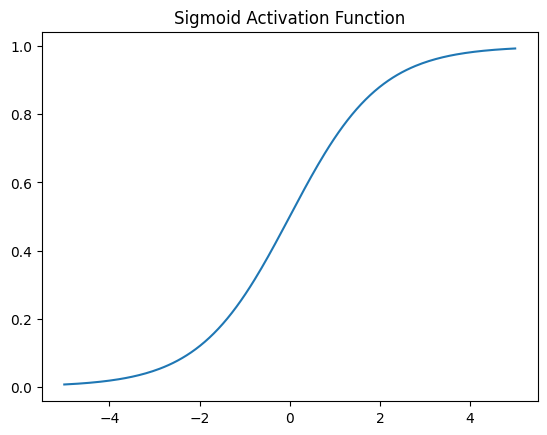

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#sigmoid
def activ(x):
        return 1/(1+np.exp(-x))

x_grid = np.linspace(-5,5,200).reshape(-1,1)
plt.title('Sigmoid Activation Function')
plt.plot(x_grid,activ(x_grid))
plt.show()

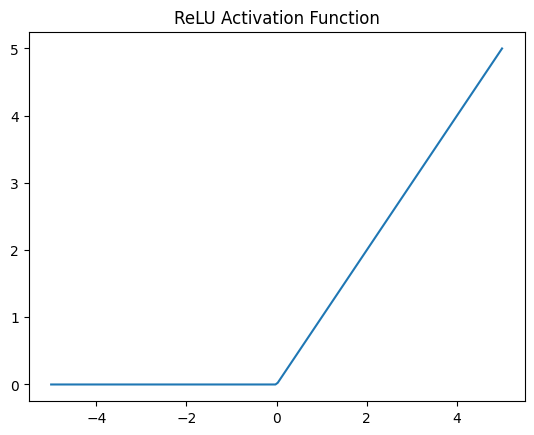

In [3]:
#ReLU
def activ(x):
        return np.maximum(0, x)
x_grid = np.linspace(-5,5,200).reshape(-1,1)
plt.title('ReLU Activation Function')
plt.plot(x_grid,activ(x_grid))

## MLP 모델의 정의와 순전파 함수 설정 

- nn.Module을 상속 받아 커스텀 모델을 만들때는 __init__과 forward 메서드를 필수로 정의 해야 한다. 
- `__init__`: 레이어와 초기 설정을 정의하는 곳, 레이어와 파라미터를 선언하고 초기화
- `forward`: 모델의 연산과정을 정의하는 메서드, 입력값을 어떻게 처리할지를 결정
    - model(input) 형식으로 간단히 모델을 호출 할 수 있다. 

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, num_input, hidden_layers, num_output, activation='relu'):
        super(MLP, self).__init__()

        self.num_input = num_input
        self.hidden_layers = hidden_layers
        self.num_output = num_output
        self.layers = [num_input]+list(hidden_layers)+[num_output]
        
        self.fc = nn.ModuleList([nn.Linear(self.layers[i], self.layers[i+1]) for i in range(len(self.layers)-1)])
                
        activation_function = {
            'relu': F.relu,
            'sigmoid': torch.sigmoid,
            'linear': F.linear
        }
        self.activation = activation_function[activation]

        for tensor in self.parameters():
            nn.init.normal_(tensor, mean=0, std=0.001)

    # 간단한 기본 forward 함수
    def forward(self, X):
        return X

## 순전파 메서드 (new forward) 정의 및 덮어쓰기 

In [8]:
def new_forward(self, X):
    for layer in self.fc[:-1]: #순차적인 레이어 통과 
        X = F.relu(layer(X)) #각 레이어에서 relu활성화 함수를 적용하여 비선형성을 추가
    X = self.fc[-1](X) #마지막 레이어에서는 활성화함수를 적용하지 않고 그대로 출력, 모델이 최종적으로 예측값을 내놓도록 하는 일반적인 설정
    return X

MLP.forward = new_forward  # 기존 forward 메서드를 새로운 메서드로 덮어쓰기

## MLP 모델 생성 및 구조 확인 

In [11]:
mlp = MLP(num_input=784, hidden_layers=(256,128,64), num_output=10)
mlp

MLP(
  (fc): ModuleList(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [12]:
print("모델 레이어 구조 (각 레이어의 뉴런 수):\n", mlp.layers, "\n")
print("모델의 모든 완전 연결 레이어 (ModuleList로 구성):\n", mlp.fc, "\n")
print("첫 번째 레이어의 가중치 값:\n", mlp.fc[0].weight, "\n")
print("첫 번째 레이어의 바이어스 값:\n", mlp.fc[0].bias, "\n")
print("모델에서 사용되는 활성화 함수:\n", mlp.activation.__name__, "\n")

모델 레이어 구조 (각 레이어의 뉴런 수):
 [784, 256, 128, 64, 10] 

모델의 모든 완전 연결 레이어 (ModuleList로 구성):
 ModuleList(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): Linear(in_features=256, out_features=128, bias=True)
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): Linear(in_features=64, out_features=10, bias=True)
) 

첫 번째 레이어의 가중치 값:
 Parameter containing:
tensor([[-8.1484e-04, -3.0463e-04,  8.2995e-04,  ...,  5.4262e-04,
         -1.6744e-03,  1.2789e-03],
        [-1.7864e-03,  6.9064e-05, -7.5281e-04,  ..., -8.6220e-04,
          3.3834e-04, -2.2247e-04],
        [ 6.6168e-04,  1.6079e-04,  6.0503e-04,  ...,  5.8909e-06,
         -3.7320e-04,  1.5102e-03],
        ...,
        [-5.4806e-04, -6.7407e-04, -2.7875e-04,  ...,  1.7248e-04,
          1.0018e-03,  2.0495e-04],
        [ 8.2021e-04, -2.6577e-04, -2.8964e-04,  ...,  7.4720e-04,
          1.6070e-04, -1.5370e-03],
        [-1.0288e-03, -8.7746e-04, -6.5228e-04,  ...,  5.8397e-04,
         -1.7652e-03, -1

In [13]:
# 모델 학습 함수 정의 
from tqdm import tqdm
import torch.optim as optim

def training(model, dataloader, n_epochs, learning_rate):
    optimizer = optim.Adam(model.parameters(),lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    total_loss = []
    total_accuracy = []

    model.train()
    for epoch in range(n_epochs):
        print(f'************* Start Epoch {epoch+1} *************')

        correct = 0
        total=0
        running_loss = 0.0

        for image, target in tqdm(dataloader):
            
            optimizer.zero_grad() 
            image = image.view(-1, 784)
            pred = model(image)  
            loss = criterion(pred, target) 
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(pred, 1)
            total += target.size(0)
            correct +=(predicted == target).sum().item()

        print(f'Training acc:{correct/total}\tTraining loss:{running_loss/total}')
        total_loss.append(running_loss/total)
        total_accuracy.append(correct/total)

    return total_accuracy, total_loss

In [14]:
#모델 학습 실행
mlp_acc, mlp_loss = training(mlp, train_loader, n_epochs=5, learning_rate=0.001)

NameError: name 'train_loader' is not defined

In [15]:
#모델 추론 함수 정의 ( inference )
def inference(model, dataloader):
    prediction = []
    model.eval()
    with torch.no_grad():
        for image, target in tqdm(dataloader):

            image = image.flatten(1)
            pred = model(image)
                       
            _, pred = torch.max(pred, 1)

            prediction.extend(pred.numpy())
    return prediction

## test 데이터에 대한 예측 결과 저장 및 레이블 분포 확인 

```python
model_pred = inference(mlp, test_loader)

test_annotation['label'] = model_pred
test_annotation['label'].value_counts()
```